# GaRField

### A Gaussian Random Field generator

## Modules

In [1]:
# Matplotlib
import matplotlib.pyplot as plt

# Numpy
import numpy as np
from numpy.random import default_rng

# Scipy
from scipy.stats import norm

# Sys
import sys

In [2]:
# GaRField
sys.path.append("../garfield")
import gaussianrandomfield as gaussrf

## GRF main

### Parameters

grf_make = True to make new field

grf_make = False to read from existing file

In [3]:
grf_make = True
grf_file = "grf.npy"

Array shape

In [4]:
grf_shape = np.array((128, 128, 128))

Gaussian distribution: mean $\mu$ and variance $\sigma^2$

In [5]:
grf_mu    = 0.0
grf_sigma = 1.0

Integer seed for RNG

In [6]:
grf_seed = 1

### Data

Init RNG with seed

In [7]:
rng = default_rng(grf_seed)

Generate new field or read from file

In [8]:
if (grf_make):
    grf = gaussrf.generate(grf_mu, grf_sigma, grf_shape, rng)
    print("Save", grf_file)
    np.save(grf_file, grf)
else:
    print("Load", grf_file)
    grf       = np.load(grf_file)
    grf_shape = grf.shape

GRF : float64 (128, 128, 128)
Save grf.npy


Check statistics

In [9]:
print("Mean :", np.mean(grf.ravel()))
print("Std  :", np.std( grf.ravel()))

Mean : -1.9992462364816581
Std  : 0.9991049388282577


Plot distribution

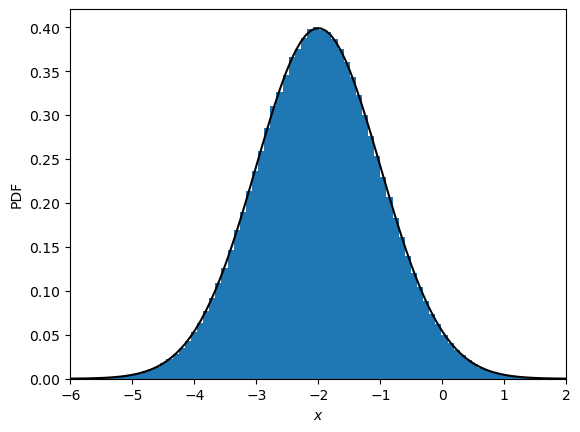

In [10]:
xmax = grf_mu + 4*grf_sigma
xmin = grf_mu - 4*grf_sigma
x = np.linspace(xmin, xmax, 100)
y = norm.pdf(x, grf_mu, grf_sigma)

plt.figure()
plt.hist(grf.ravel(), bins=100, density=True)
plt.plot(x, y, 'k')
plt.xlim(xmin, xmax)
plt.xlabel(r'$x$')
plt.ylabel('PDF')
plt.show()

## GRF Low-resolution

### Parameters

Array shape

In [11]:
glr_shape = grf_shape//2

Output file

In [12]:
glr_file = "grf_lr.npy"

### Data

Generate low-res GRF that preserves large-scale modes from base GRF

In [13]:
if (np.all(glr_shape <= grf_shape)):
    glr = gaussrf.decrease_resolution(grf, glr_shape)
else:
    print("Dimensions are incorrect")
    exit()

GRF hr            : float64 (128, 128, 128)
GRF hr transformed: complex128 (128, 128, 65)
GRF lr transformed: complex128 (64, 64, 33)
GRF lr            : float64 (64, 64, 64)


Save GRF low-res

In [14]:
print("Save", glr_file)
np.save(glr_file, glr)

Save grf_lr.npy


Check moments

In [15]:
print("Mean :", np.mean(glr.ravel()))
print("Std  :", np.std( glr.ravel()))

Mean : -1.9992462364816586
Std  : 0.9927301426997835


Plot distribution

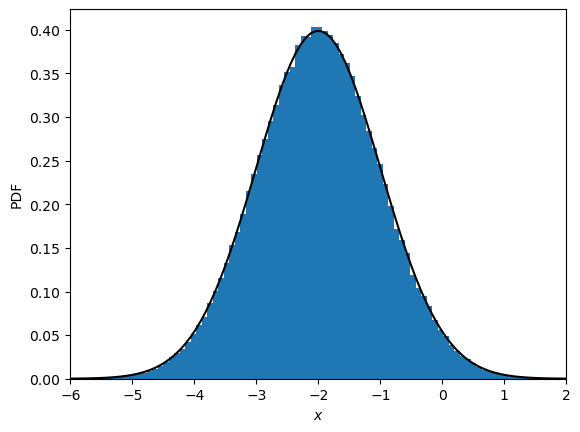

In [16]:
xmax = grf_mu + 4*grf_sigma
xmin = grf_mu - 4*grf_sigma
x = np.linspace(xmin, xmax, 100)
y = norm.pdf(x, grf_mu, grf_sigma)

plt.figure()
plt.hist(glr.ravel(), bins=100, density=True)
plt.plot(x, y, 'k')
plt.xlim(xmin, xmax)
plt.xlabel(r'$x$')
plt.ylabel('PDF')
plt.show()

## GRF High-resolution

### Parameters

Array shape

In [17]:
ghr_shape = grf_shape*2

Output file

In [18]:
ghr_file = "grf_hr.npy"

Integer seed for RNG

In [19]:
ghr_seed = 2

## Data

Init RNG with seed

In [20]:
rng_hr = default_rng(ghr_seed)

Generate high-resolution GRF that preserves large-scale modes from base GRF

In [21]:
if (np.all(ghr_shape >= grf_shape)):
    ghr = gaussrf.increase_resolution(grf, ghr_shape, rng_hr)
else:
    print("Dimensions are incorrect")
    exit()

GRF lr            : float64 (128, 128, 128)
GRF lr transformed: complex128 (128, 128, 65)
GRF : float64 (512, 512, 512)
GRF hr transformed: complex128 (512, 512, 257)
GRF hr            : float64 (512, 512, 512)


Save high-res GRF

In [22]:
print("Save", ghr_file)
np.save(ghr_file, ghr)

Save grf_hr.npy


Check moments

In [23]:
print("Mean :", np.mean(ghr.ravel()))
print("Std  :", np.std( ghr.ravel()))

Mean : -1.9992462364816581
Std  : 0.9990587846350784


Plot distribution

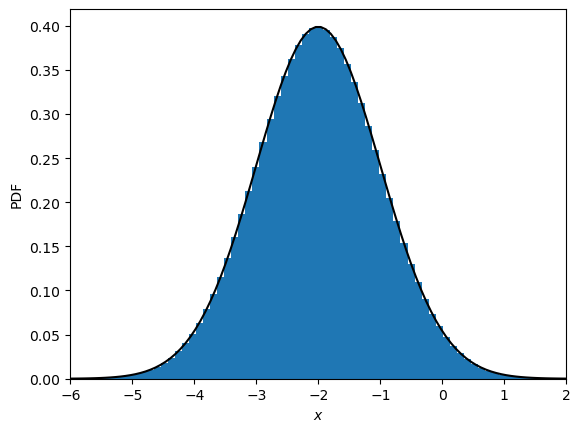

In [24]:
xmax = grf_mu + 4*grf_sigma
xmin = grf_mu - 4*grf_sigma
x = np.linspace(xmin, xmax, 100)
y = norm.pdf(x, grf_mu, grf_sigma)

plt.figure()
plt.hist(ghr.ravel(), bins=100, density=True)
plt.plot(x, y, 'k')
plt.xlim(xmin, xmax)
plt.xlabel(r'$x$')
plt.ylabel('PDF')
plt.show()